 ## importation des dépendances 

In [2]:
import numpy as np 
import matplotlib.pyplot as plt 
import pandas as pd

from sklearn.tree import DecisionTreeRegressor, plot_tree
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error

import seaborn as sns


# objectif étant de predire la valeur des appartements en fonction de leurs caractéristiques

## Le fichier de lien peut être télécharger depuis la platforme : 
https://www.kaggle.com/harrywang/housing
- longitude : Longitude de la localisation du logement
- latitude : Latitude de la localisation du logement
- housing_median_age : Âge médian des logements dans la région
- total_rooms : Nombre total de chambres dans la région
- total_bedrooms : Nombre total de chambres à coucher dans la région
- population : Population totale dans la région
- households : Nombre total de ménages dans la région
- median_income : Revenu médian des ménages dans la région
- median_house_value : Valeur médiane des maisons dans la région
- ocean_proximity

In [3]:
# importation des données 

data= pd.read_csv('housing.csv', sep = ";", decimal=',')
data = pd.DataFrame(data)
data.describe()


,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value
count,20640.000000,20640.000000,20640.000000,20640.000000,20433.000000,20640.000000,20640.000000,20640.000000,20640.000000
mean,-119.569704,35.631861,28.639486,2635.763081,537.870553,1425.476744,499.539680,3.870671,206855.816909
std,2.003532,2.135952,12.585558,2181.615252,421.385070,1132.462122,382.329753,1.899822,115395.615874
min,-124.350000,32.540000,1.000000,2.000000,1.000000,3.000000,1.000000,0.499900,14999.000000
25%,-121.800000,33.930000,18.000000,1447.750000,296.000000,787.000000,280.000000,2.563400,119600.000000
50%,-118.490000,34.260000,29.000000,2127.000000,435.000000,1166.000000,409.000000,3.534800,179700.000000
75%,-118.010000,37.710000,37.000000,3148.000000,647.000000,1725.000000,605.000000,4.743250,264725.000000
max,-114.310000,41.950000,52.000000,39320.000000,6445.000000,35682.000000,6082.000000,15.000100,500001.000000


In [4]:
# verification de l'etat des données
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20640 entries, 0 to 20639
Data columns (total 10 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   longitude           20640 non-null  float64
 1   latitude            20640 non-null  float64
 2   housing_median_age  20640 non-null  float64
 3   total_rooms         20640 non-null  int64  
 4   total_bedrooms      20433 non-null  float64
 5   population          20640 non-null  int64  
 6   households          20640 non-null  int64  
 7   median_income       20640 non-null  float64
 8   median_house_value  20640 non-null  int64  
 9   ocean_proximity     20640 non-null  object 
dtypes: float64(5), int64(4), object(1)
memory usage: 1.6+ MB


In [5]:
# visualisation des 5 premières lignes
data.head()

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value,ocean_proximity
0,-122.23,37.88,41.0,880,129.0,322,126,8.3252,452600,NEAR BAY
1,-122.22,37.86,21.0,7099,1106.0,2401,1138,8.3014,358500,NEAR BAY
2,-122.24,37.85,52.0,1467,190.0,496,177,7.2574,352100,NEAR BAY
3,-122.25,37.85,52.0,1274,235.0,558,219,5.6431,341300,NEAR BAY
4,-122.25,37.85,52.0,1627,280.0,565,259,3.8462,342200,NEAR BAY


In [7]:
# verification de l'existance de colonnes nulles 
data.isnull().sum()

longitude               0
latitude                0
housing_median_age      0
total_rooms             0
total_bedrooms        207
population              0
households              0
median_income           0
median_house_value      0
ocean_proximity         0
dtype: int64

In [8]:
# visualisation de la taille de la data pour voir si 207 valeur nulle peuvent influencer négativement la véracité de cette dataset
data.shape

(20640, 10)

In [9]:
#suppression de valeur nulle (remplacement par 0)

data['total_bedrooms'].fillna(0, inplace=True)

C:\Users\couli\AppData\Local\Temp\ipykernel_7068\835944828.py:3: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  data['total_bedrooms'].fillna(0, inplace=True)


In [10]:
# verification des modification faites sur la dataset
data.isnull().sum()

longitude             0
latitude              0
housing_median_age    0
total_rooms           0
total_bedrooms        0
population            0
households            0
median_income         0
median_house_value    0
ocean_proximity       0
dtype: int64

Index(['longitude', 'latitude', 'housing_median_age', 'total_rooms',
       'total_bedrooms', 'population', 'households', 'median_income',
       'median_house_value'],
      dtype='object')


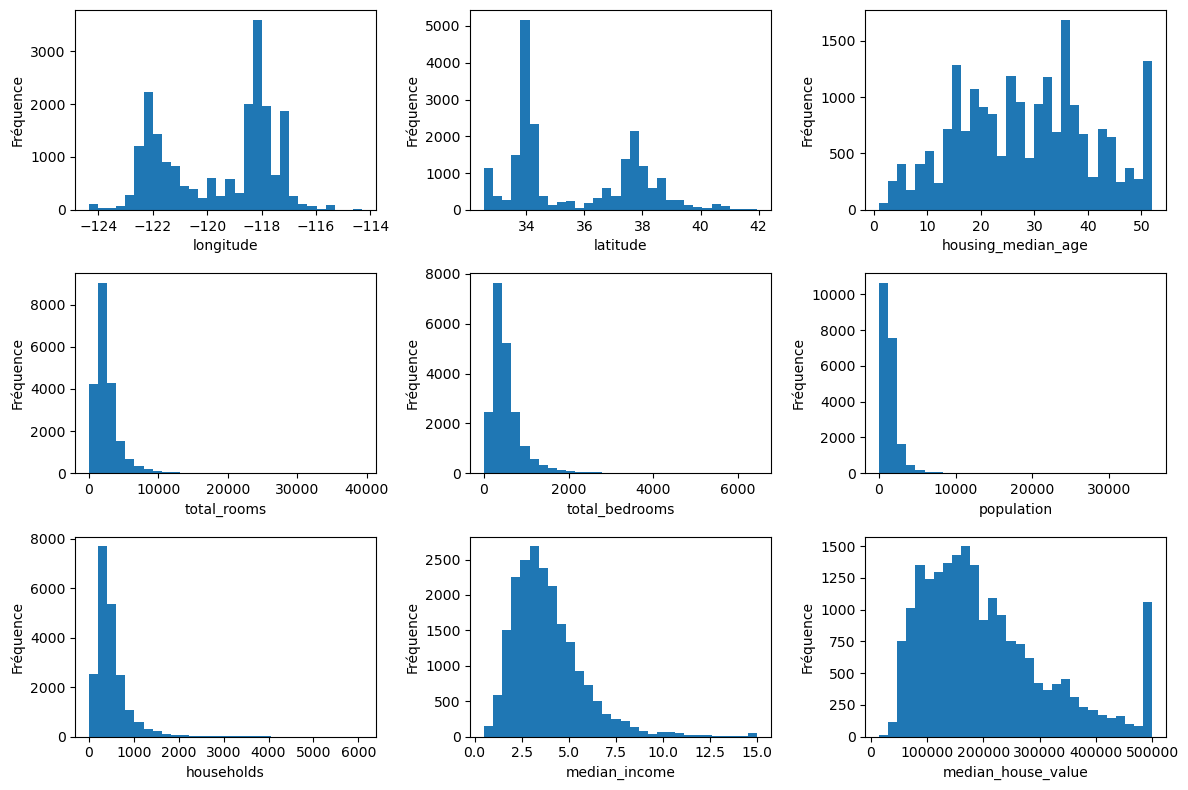

In [6]:
# description de la fréquence d'apparition des valeurs quantitatives de la dataset afin de comprendre  et traiter ces dernières

# recuperation des lignes contenants des valeurs quantitatives dans la dataset 

quant_val = data.select_dtypes(include = np.number).columns
# creation d'un subplot(ensemble de plot) afin de visualiser la frequence d'apparition des valeurs quantitatives

print (quant_val)
fig, axs = plt.subplots(nrows = 3 , ncols = 3, figsize =(12, 8))

axs = axs.flatten()
# retour un format (key, value) ou la clée est est l'indice de l'élément et la valeur est la donnée
for i, var in enumerate(quant_val): 
    axs[i].hist(data[var], bins = 30) # mise en place concrète de l'histogramme avec le bins qui fixe l'épaisseur des barres
    axs[i].set_xlabel(var)
    axs[i].set_ylabel('Fréquence')
plt.tight_layout()
plt.show()


## Visualisation de la repartission des données caractéristiques de la proximité des appartements par rapport à l'ocean 

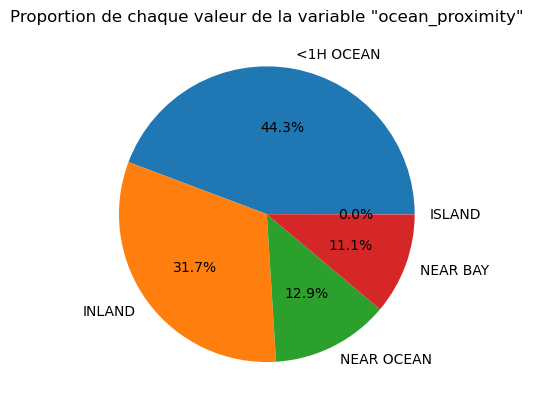

In [12]:
# variable count par indice de proximité 
prop_counts = data['ocean_proximity'].value_counts(normalize= True)

# création d'un pie 

plt.pie(prop_counts, labels = prop_counts.index, autopct = '%1.1f%%')
plt.title('Proportion de chaque valeur de la variable "ocean_proximity"')
plt.show()

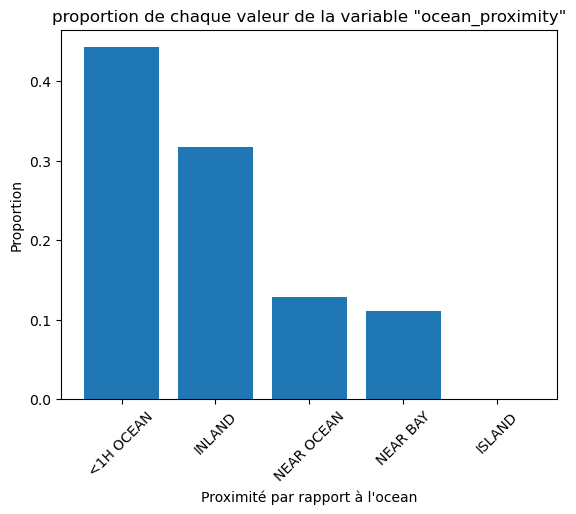

In [13]:
# on peut aussi visualiser l'histogramme pour se faire une idée plus claire de cette repartission

prox_counts= data['ocean_proximity'].value_counts(normalize = True)

# creation d'un barplot

plt.bar(x = prox_counts.index , height = prox_counts)
plt.xticks(rotation=45)
plt.xlabel("Proximité par rapport à l'ocean")
plt.ylabel("Proportion")
plt.title('proportion de chaque valeur de la variable "ocean_proximity"')
plt.show()

# Analyse des variables pertinantes qui peuvent faire l'objet de notre étude

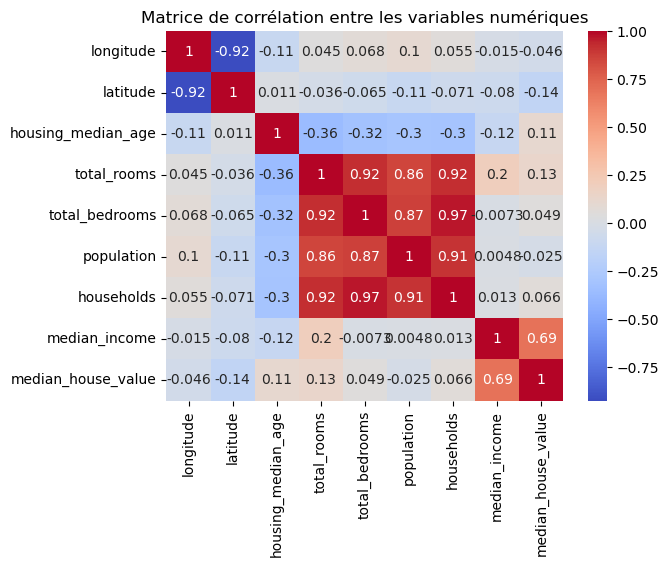

In [14]:
# matrice de corelation afin de visualiser les dependances pertinantes entre les variables

corr_matrix = data.select_dtypes(include = np.number).corr()
sns.heatmap(corr_matrix, annot = True, cmap = 'coolwarm' )  
plt.title('Matrice de corrélation entre les variables numériques')
plt.show()

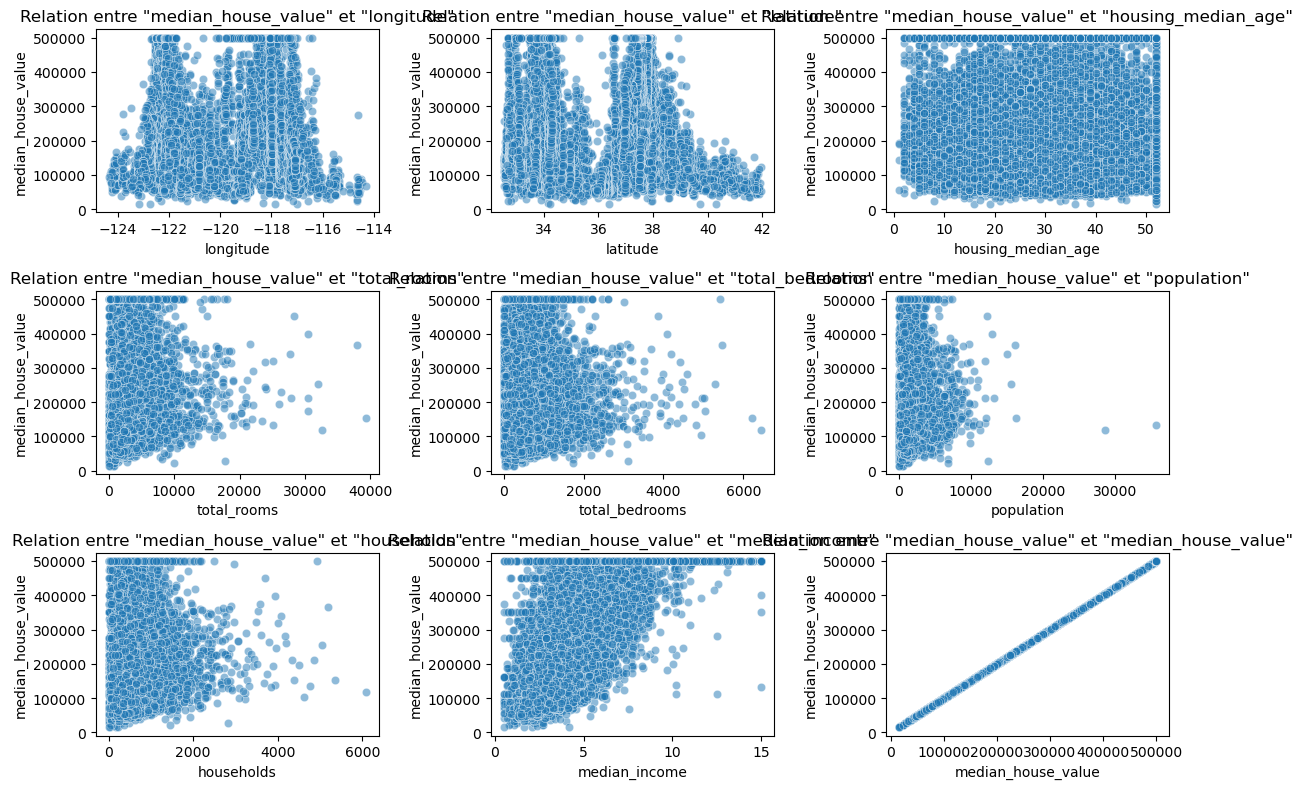

In [15]:
# On cherche maintenant à determiner la relation entre la valeur moyenne des maisons et les autres variables; on utilisera scatter (nuage de points) pour ce faire

num_vars = data.select_dtypes(include = np.number).columns 

fig, axs = plt.subplots(nrows = 3, ncols= 3, figsize=(12,8))
axs= axs.flatten()

for i, var in enumerate(num_vars):
    sns.scatterplot(x= var, y= 'median_house_value', data = data, alpha = 0.5, ax = axs[i])
    axs[i].set_title('Relation entre "median_house_value" et "{}"'.format(var))

# Ajout des titres et des étiquettes des axes
plt.tight_layout()
plt.show()



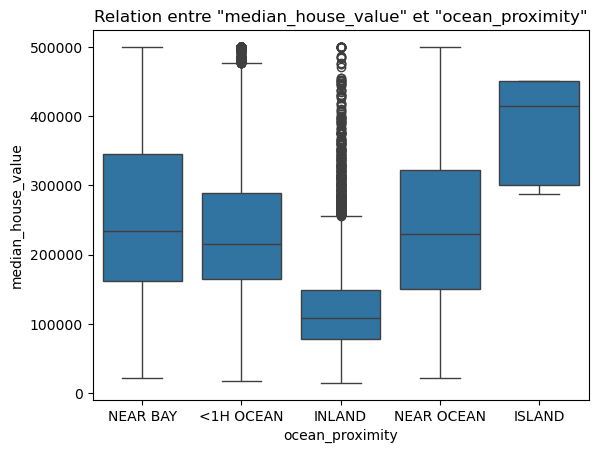

In [16]:
# on va maintenant visualiser la relation entre la variable "median_house_value et la proximité de l'ocean

sns.boxplot (x = 'ocean_proximity', y= 'median_house_value', data = data)
plt.title('Relation entre "median_house_value" et "ocean_proximity"')
plt.show()


In [ ]:
sns.pairplot(data[num_vars])
plt.show()

## phase d'entrainement du model et de test

In [18]:
# remplacemdnt des variables catégorielles en variables quantitative (  dans la colonne "ocean_proximity")
from sklearn.preprocessing import OneHotEncoder

# Sélection des variables catégorielles
cat_vars = ['ocean_proximity']

# Encodage binaire des variables catégorielles
encoder = OneHotEncoder(sparse_output=False)
cat_data = pd.DataFrame(encoder.fit_transform(data[cat_vars]))
cat_data.columns = encoder.get_feature_names_out(cat_vars)

# Remplacement des variables catégorielles par les variables encodées
data = pd.concat([data.drop(cat_vars, axis=1), cat_data], axis=1)


In [19]:
data

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value,ocean_proximity_<1H OCEAN,ocean_proximity_INLAND,ocean_proximity_ISLAND,ocean_proximity_NEAR BAY,ocean_proximity_NEAR OCEAN
0,-122.23,37.88,41.0,880,129.0,322,126,8.3252,452600,0.0,0.0,0.0,1.0,0.0
1,-122.22,37.86,21.0,7099,1106.0,2401,1138,8.3014,358500,0.0,0.0,0.0,1.0,0.0
2,-122.24,37.85,52.0,1467,190.0,496,177,7.2574,352100,0.0,0.0,0.0,1.0,0.0
3,-122.25,37.85,52.0,1274,235.0,558,219,5.6431,341300,0.0,0.0,0.0,1.0,0.0
4,-122.25,37.85,52.0,1627,280.0,565,259,3.8462,342200,0.0,0.0,0.0,1.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
20635,-121.09,39.48,25.0,1665,374.0,845,330,1.5603,78100,0.0,1.0,0.0,0.0,0.0
20636,-121.21,39.49,18.0,697,150.0,356,114,2.5568,77100,0.0,1.0,0.0,0.0,0.0
20637,-121.22,39.43,17.0,2254,485.0,1007,433,1.7000,92300,0.0,1.0,0.0,0.0,0.0
20638,-121.32,39.43,18.0,1860,409.0,741,349,1.8672,84700,0.0,1.0,0.0,0.0,0.0


In [20]:

# Séparation des données en variables explicatives et variable cible
X = data.drop('median_house_value', axis=1)
y = data['median_house_value'] 


In [21]:
data

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value,ocean_proximity_<1H OCEAN,ocean_proximity_INLAND,ocean_proximity_ISLAND,ocean_proximity_NEAR BAY,ocean_proximity_NEAR OCEAN
0,-122.23,37.88,41.0,880,129.0,322,126,8.3252,452600,0.0,0.0,0.0,1.0,0.0
1,-122.22,37.86,21.0,7099,1106.0,2401,1138,8.3014,358500,0.0,0.0,0.0,1.0,0.0
2,-122.24,37.85,52.0,1467,190.0,496,177,7.2574,352100,0.0,0.0,0.0,1.0,0.0
3,-122.25,37.85,52.0,1274,235.0,558,219,5.6431,341300,0.0,0.0,0.0,1.0,0.0
4,-122.25,37.85,52.0,1627,280.0,565,259,3.8462,342200,0.0,0.0,0.0,1.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
20635,-121.09,39.48,25.0,1665,374.0,845,330,1.5603,78100,0.0,1.0,0.0,0.0,0.0
20636,-121.21,39.49,18.0,697,150.0,356,114,2.5568,77100,0.0,1.0,0.0,0.0,0.0
20637,-121.22,39.43,17.0,2254,485.0,1007,433,1.7000,92300,0.0,1.0,0.0,0.0,0.0
20638,-121.32,39.43,18.0,1860,409.0,741,349,1.8672,84700,0.0,1.0,0.0,0.0,0.0


In [22]:
# diviser la base en train et test
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# implémentation du model
model = DecisionTreeRegressor()
model.fit(X_train, y_train)


,criterion,'squared_error'
,splitter,'best'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,None
,random_state,None
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,ccp_alpha,0.0


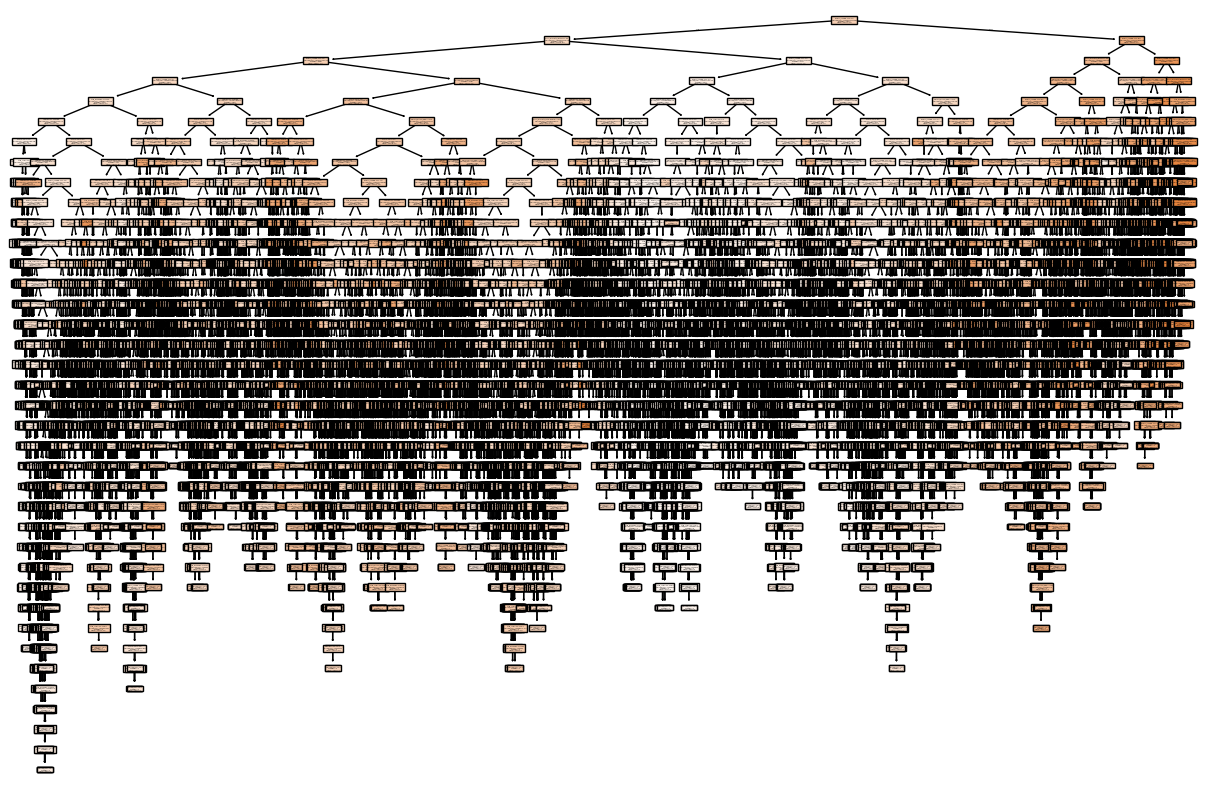

In [23]:
# visualisation de l'abre 

plt.figure(figsize =(15,10))
plot_tree(model,feature_names = X_train.columns,filled= True)
plt.show()

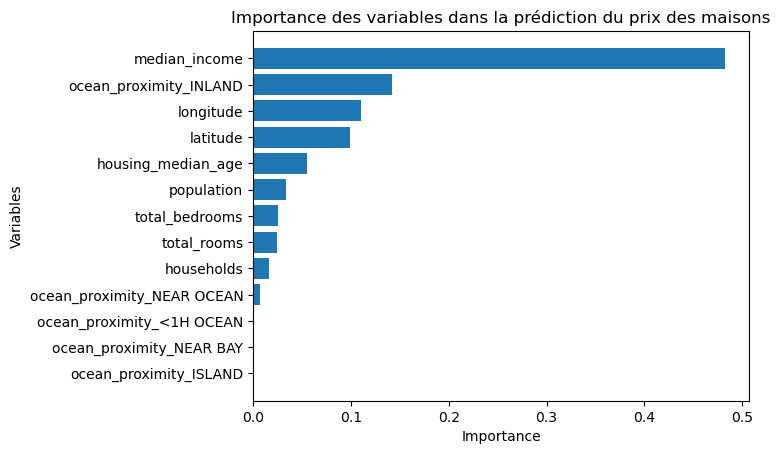

In [26]:
# affichage de l'importance des variables 

importances = pd.Series(model.feature_importances_, index=X_train.columns)
importances_sorted = importances.sort_values()
plt.barh(importances_sorted.index, importances_sorted)
plt.title('Importance des variables dans la prédiction du prix des maisons')
plt.xlabel('Importance')
plt.ylabel('Variables')
plt.show()


In [ ]:
# prediction à partir du model entrainé de la valeur d'une maison en se basant sur les autres données d'entrainement et de test
y_train_pred = model.predict(X_train)
y_test_pred = model.predict(X_test)

# Calcule du RMSE ainsi que d'autre valeurs de performance du model
from sklearn.metrics import accuracy_score
X_train_rmse= metrics.accuracy_score(y_pred, y_test)+
